# **Steam Game Popularity Prediction**
By: Jonathan Barroso, Bruno Oros, and Abhi Ramireddy

The group project selected will study how applying data from 2024 and 2025 can help predict which games will be popular in the future. Steam is an online marketplace that sells digital copies of video games. The objective would be to take the critic scores of each game, both by professional critics and by regular everyday gamers, and use them to determine what have been the most popular games played between 2024 and 2025. These numbers will be used to train an AI model in order to predict what games will be popular in the near future

# **Step 1: Introduction/Background**

The global gaming industry is one of the most profitable industries as a whole. According to forbes, the revenue statistics in 2022 show the following:

*   The global gaming industry generated an estimated \$184.4 billion
*   The global recorded music industry generated an estimated \$26.2 billion
*   The global movie industry generated an estimated \$26 billion at the box office


This makes the gaming industry a very interesting topic as gamemakers constantly need to think about what games are popular, and what will be trending in the near future. We explore very interesting questions including but not limited to:

1.   Does being a reputable publisher relate to a higher success rate?
2.   How do game genres influence their estimated financial success?
3.   Does the number of achievements correlate with average playtime?

These questions seek to find what different features lead to the success of a game. Measuring success can be a difficult task as what does it mean to have a successful game? Is it the most revenue? Most user engagement? Or is it more about positive reviews on the game? We seek to understand what kind of correlations can be found based on the dataset we have found. This is based on a steam database that tracks games sold on their platform. Steam is one of the largest online gaming marketplaces in the industry. This makes the dataset a reliable representation of the gaming scene. We will use this to ultimately try to make a model that can predict upcoming popular games.

In [1]:
# import packages
import json
import glob
import pandas as pd
import numpy as np
import datetime as dt
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns


from matplotlib import cm
from google.colab import drive


from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import torch
import torchvision
from torchvision import transforms, utils
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from collections import Counter
import seaborn as sns
import matplotlib.ticker as mtick
import scipy.stats as stats
from scipy.stats import f_oneway
from matplotlib.ticker import FuncFormatter

In [2]:
%%capture
!apt update
!pip install kaggle

In [3]:
# Run this cell to mount your drive (you will be prompted to sign in)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Create the kaggle directory and
# (NOTE: Do NOT run this cell more than once unless restarting kernel)
!mkdir ~/.kaggle

In [5]:
# Read the uploaded kaggle.json file
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/

In [6]:
# Download dataset
!!kaggle datasets download -d artermiloff/steam-games-dataset

['Dataset URL: https://www.kaggle.com/datasets/artermiloff/steam-games-dataset',
 'License(s): MIT']

In [7]:
# Unzip folder in Colab content folder
!unzip /content/steam-games-dataset.zip

Archive:  /content/steam-games-dataset.zip
  inflating: games_march2025_cleaned.csv  
  inflating: games_march2025_full.csv  
  inflating: games_may2024_cleaned.csv  
  inflating: games_may2024_full.csv  


In [8]:
# TO-DO: Read the csv files and save it to dataframes
games_march2025_cleaned = pd.read_csv('/content/games_march2025_cleaned.csv')
games_march2025_full = pd.read_csv('/content/games_march2025_full.csv')
games_may2024_cleaned = pd.read_csv('/content/games_may2024_cleaned.csv')
games_may2024_full = pd.read_csv('/content/games_may2024_full.csv')

# **Part 2A: Processing Data**
Here we added a Game of the Year feature so that the AI model can also consider which games have gotten game of the year.

In [9]:
#list of games that have won Game of the Year
GOTY_list = ['Dragon Age: Inquisition',
             'The Witcher 3: Wild Hunt',
             'Overwatch',
             'The Legend of Zelda: Breath of the Wild',
             'God of War',
             'Sekiro: Shadows Die Twice',
             'The Last of Us Part II',
             'It Takes Two',
             'Elden Ring',
             'Baldur\'s Gate 3',
             'Astro Bot'
             ]

In [10]:
#add a column that contains a 1 if the game is GOTY and a 0 if not
games_march2025_cleaned['isGOTY'] = games_march2025_cleaned['name'].apply(lambda x: 1 if x in GOTY_list else 0)
games_march2025_full['isGOTY'] = games_march2025_full['name'].apply(lambda x: 1 if x in GOTY_list else 0)
games_may2024_cleaned['isGOTY'] = games_may2024_cleaned['name'].apply(lambda x: 1 if x in GOTY_list else 0)
games_may2024_full['isGOTY'] = games_may2024_full['name'].apply(lambda x: 1 if x in GOTY_list else 0)

Finally we make the final_df that will be used in the regression models and neural networks. This will include information from the games of may 2024 and march 2025 as we seek to use data over the course of a year to help create the most accurate models possible.

In [11]:
if 'discount' not in games_may2024_cleaned.columns:
    games_may2024_cleaned['discount'] = 0
games_may2024_cleaned = games_may2024_cleaned.rename(columns={'AppID': 'appid'})
df_merged = pd.merge(
    games_may2024_cleaned,
    games_march2025_cleaned,
    on='appid',
    how='outer',
    suffixes=('_2024', '_2025')
)

# Columns to prioritize from 2025 (fall back to 2024 if missing)
columns_to_prioritize = ['num_reviews_total', 'user_score', 'required_age',
                         'discount', 'price', 'dlc_count', 'isGOTY', 'metacritic_score']

# Create final dataframe
final_df = pd.DataFrame()
final_df['appid'] = df_merged['appid']

for col in columns_to_prioritize:
    col_2025 = col + '_2025'
    col_2024 = col + '_2024'

    if col_2025 in df_merged.columns and col_2024 in df_merged.columns:
        final_df[col] = df_merged[col_2025].combine_first(df_merged[col_2024])
    elif col_2025 in df_merged.columns:
        final_df[col] = df_merged[col_2025]
    elif col_2024 in df_merged.columns:
        final_df[col] = df_merged[col_2024]

# Drop rows with missing essential values
final_df = final_df.dropna(subset=['user_score', 'num_reviews_total'])

# Add log of review count
final_df['log_reviews'] = np.log1p(final_df['num_reviews_total'])

# Add release_date to final_df
final_df['release_date'] = df_merged['release_date_2025'].combine_first(df_merged['release_date_2024'])

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


# **Part 2B: Exploratory Data Analysis & Feature Engineering**

# Exploring data with questions!

### **Question 1: Does being a reputable publisher relate to a higher success rate?**

To explore this, we first defined two key metrics from the data:

- **Publisher Reputation**: Measured as the **average success of a publisher’s past games** prior to the release of each new title. This proxy for reputation is calculated by aggregating historical success metrics (derived from the proportion of positive user reviews) for each publisher. Values range from 0 (indicating a poor track record) to 1 (signaling a highly successful history).

- **Game Success**: Defined as the **proportion of positive user reviews** for a given game (expressed via the `pct_pos_total` metric) and normalized to a 0–1 scale. Higher values reflect a game that has been well-received by its audience.

In our analysis, we merged historical game data and applied an expanding window to compute each publisher’s past average success, as well as additional metrics like past hit counts (the number of previous games surpassing a defined success threshold). We then visualized trends using decile binning with error bars and applied LOWESS smoothing on scatter plots to capture non-linear trends. Finally, we quantified the relationship via Pearson correlation and simple linear regression. This multi-faceted approach allows us to assess whether a reputable publisher indeed correlates with higher game success.


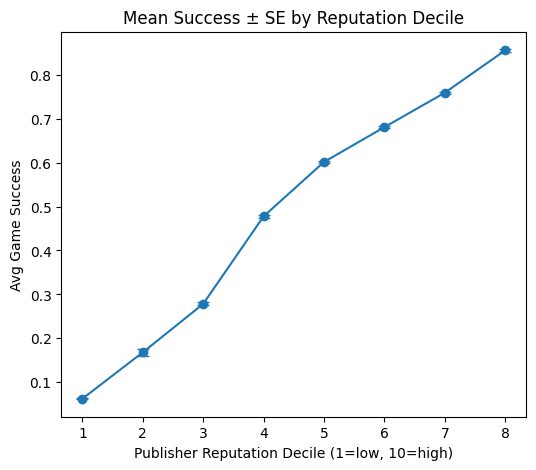

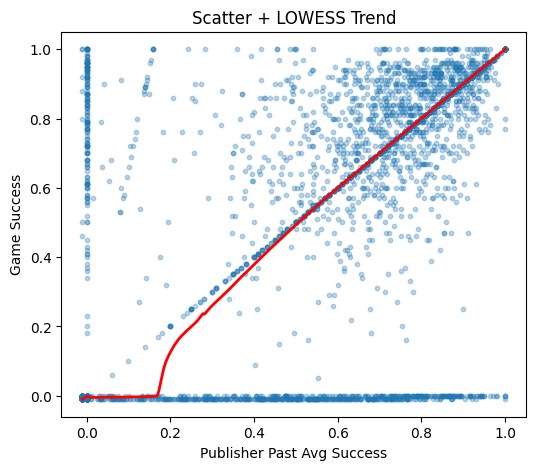

Pearson r between reputation and success: 0.743
Linear regression: success = 0.801*rep + 0.058
Test R² = 0.554


In [12]:
!pip install statsmodels
import statsmodels.api as sm

# -----------------------------------------------
# Publisher Reputation Analysis
# -----------------------------------------------

# 1) Prepare all_games
games_2024 = games_may2024_cleaned[['appid','release_date','publishers','pct_pos_total']]
games_2025 = games_march2025_cleaned[['appid','release_date','publishers','pct_pos_total']]
all_games = pd.concat([games_2024, games_2025], ignore_index=True)

# define success metric
all_games['success'] = all_games['pct_pos_total'] / 100.0

# explode publisher list
all_games = (
    all_games
    .assign(publisher=all_games['publishers'].str.split(';'))
    .explode('publisher')
    .dropna(subset=['publisher'])
)

# sort by publisher & date for correct expanding windows
all_games = all_games.sort_values(['publisher','release_date'])

# 2) Compute past_avg_success with shift + expanding.mean()
all_games['past_avg_success'] = (
    all_games
    .groupby('publisher')['success']
    .apply(lambda s: s.shift().expanding().mean())      # expanding mean per group
    .reset_index(level=0, drop=True)                    # align series index back to all_games
)

# 3) Compute past_hits similarly (count of prior games above threshold)
threshold = 0.8
all_games['past_hits'] = (
    all_games
    .groupby('publisher')['success']
    .apply(lambda s: (s.shift() >= threshold).expanding().sum())
    .reset_index(level=0, drop=True)
)

# 4) Aggregate back up to game level
pub_metrics = (
    all_games
    .groupby(['appid','release_date'])
    .agg(
        publisher_rep = ('past_avg_success','mean'),
        publisher_hits = ('past_hits','mean')
    )
    .reset_index()
)

# 5) Merge into your final_df
# Include 'pct_pos_total' from games_may2024_cleaned in the merge
# Ensure 'appid' is in both DataFrames for merging
# Merge 'pct_pos_total' earlier in the process

if 'pct_pos_total' not in final_df.columns:
    final_df = final_df.merge(
        games_may2024_cleaned[['appid', 'pct_pos_total']],
        on='appid',
        how='left'
    )

# Merge publisher metrics, but drop existing columns to avoid conflicts
final_df = final_df.drop(columns=['publisher_rep', 'publisher_hits'], errors='ignore') \
    .merge(
    pub_metrics[['appid', 'publisher_rep', 'publisher_hits']],
    on='appid',
    how='left'
)
#print(final_df.columns) # Debugging line to print the columns of final_df

# fill missing reputations (e.g. new publishers) with 0
final_df[['publisher_rep','publisher_hits']] = final_df[['publisher_rep','publisher_hits']].fillna(0)
final_df['pct_pos_total'] = final_df['pct_pos_total'].fillna(0) # Fill pct_pos_total NaNs

# define a 0–1 success column
final_df['success'] = final_df['pct_pos_total'] / 100.0

# -----------------------------------------------------------------------------
# 1) Binned averages (deciles) with error bars
# -----------------------------------------------------------------------------
# create 10 decile bins (duplicates='drop' just in case of ties)
final_df['rep_decile'] = pd.qcut(final_df['publisher_rep'], 10, labels=False, duplicates='drop')

# compute mean, std, count per decile
summary = (
    final_df
    .groupby('rep_decile')['success']
    .agg(['mean','std','count'])
    .reset_index()
)

# plot mean ± SE
plt.figure(figsize=(6,5))
plt.errorbar(
    summary['rep_decile'] + 1,              # show 1–10
    summary['mean'],
    yerr=summary['std'] / np.sqrt(summary['count']),
    fmt='o-',
    capsize=4
)
plt.xticks(summary['rep_decile'] + 1)
plt.xlabel('Publisher Reputation Decile (1=low, 10=high)')
plt.ylabel('Avg Game Success')
plt.title('Mean Success ± SE by Reputation Decile')
plt.show()


# -----------------------------------------------------------------------------
# 2) Scatter + LOWESS smoothing
# -----------------------------------------------------------------------------
sample = final_df.sample(5000, random_state=1)

lowess = sm.nonparametric.lowess
z = lowess(sample['success'], sample['publisher_rep'], frac=0.3)

plt.figure(figsize=(6,5))
plt.scatter(sample['publisher_rep'], sample['success'], alpha=0.3, s=10)
plt.plot(z[:,0], z[:,1], 'r-', linewidth=2)
plt.xlabel('Publisher Past Avg Success')
plt.ylabel('Game Success')
plt.title('Scatter + LOWESS Trend')
plt.show()


# -----------------------------------------------------------------------------
# 3) Pearson correlation & simple linear regression
# -----------------------------------------------------------------------------
# Pearson r
corr = final_df[['publisher_rep','success']].corr().loc['publisher_rep','success']
print(f"Pearson r between reputation and success: {corr:.3f}")

# Linear regression
X = final_df[['publisher_rep']].values
y = final_df['success'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

model = LinearRegression().fit(X_train, y_train)
r2 = model.score(X_test, y_test)
coef = model.coef_[0]
intercept = model.intercept_

print(f"Linear regression: success = {coef:.3f}*rep + {intercept:.3f}")
print(f"Test R² = {r2:.3f}")

# Answer to 1

Yes, being a reputable publisher is clearly associated with a higher success rate. Several pieces of evidence support this conclusion:

- **Statistical Measures:**  
  - The Pearson correlation coefficient (r = 0.743) indicates a moderately strong positive relationship between publisher reputation and game success.
  - A linear regression model gives the equation:  
    `success = 0.801 × reputation + 0.058`  
    with an R² of 0.554, meaning reputation explains about 55% of the variation in success.

- **Visual Analysis:**  
  - **Decile Analysis:** Grouping games by publisher reputation decile shows a clear upward trend in average success as reputation increases.
  - **Scatter Plot with LOWESS Smoothing:** Despite individual data variability, the smoothed trend line further confirms that higher publisher reputation correlates with improved game success.

Together, these findings provide robust evidence that a publisher’s historical performance is a key predictor of a game's success.

### **Question 2: How do game genres influence their estimated financial success?**

To explore this, we first defined two key metrics from the data:

- **Genre**: Each game is associated with one or more genres. We processed the genre information by splitting the genre strings on commas, trimming any extra spaces, and filtering out categories not directly related to video games (e.g., Game Development, Animation & Modeling, etc.). This ensures our analysis focuses solely on bona fide video game genres.

- **Estimated Revenue**: In the absence of direct sales data, we approximate financial success by calculating the product of a game's price and its estimated average number of owners. The average number of owners is computed by parsing a string range (e.g., "1000 - 5000") into a single average value. We then aggregate these individual revenue estimates to derive key statistics such as average price, average reviews, average revenue, and total revenue per genre.

By using these definitions, we group the data by genre and analyze trends in estimated revenue. This approach enables us to identify which game categories tend to perform best financially, thereby uncovering valuable insights into market trends and consumer preferences.

In [13]:
#copy the dataframe
genre_profitability = games_march2025_cleaned.copy()

In [14]:
"""
This function is to parse through the estimated owners and convert them
to a single average number
"""
def parse_est_owners(x):
    try:
        low, high = x.split(' - ')
        return (int(low) + int(high)) / 2
    except:
        return np.nan

#call the made function to parse through the feature 'estimated_owners'
genre_profitability['owners_avg'] = genre_profitability['estimated_owners'].apply(parse_est_owners)

#calculate the estimated revenue as the price of the games times the estimated average amount of owners
genre_profitability['est_revenue'] = genre_profitability['price'] * genre_profitability['owners_avg']

In [15]:
#Step 1: Clean the data before grouping
#establish a list of categories that are not video games but are sold through steam
non_game_genres = {
    'Game Development', 'Animation & Modeling', 'Photo Editing',
    'Web Publishing', 'Design & Illustration', 'Utilities',
    'Education', 'Video Production', 'Audio Production'
}

#remove nulls and zero'd out values from estimated_owners
genre_profitability = genre_profitability[
    genre_profitability['estimated_owners'].notna() &
    (genre_profitability['estimated_owners'] != '0 - 0')
]

#replace invalid review counts with NaN
genre_profitability.loc[:, 'num_reviews_total'] = genre_profitability['num_reviews_total'].replace(-1, np.nan)
#drop rows with missing review counts
genre_profitability = genre_profitability[genre_profitability['num_reviews_total'].notna()]

<ipython-input-15-ed9844b98583>:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[8632939. 2513842. 2452595. ...      nan      nan      nan]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  genre_profitability.loc[:, 'num_reviews_total'] = genre_profitability['num_reviews_total'].replace(-1, np.nan)


In [16]:
#fill missing genres with empty string and strip the genres, remove empty genres
genre_profitability['genres_list'] = genre_profitability['genres'].fillna('').apply(
    lambda x: [g.strip() for g in x.split(',') if g.strip()]
)

#explode the genre_profitabitilty at genres_list
genre_profitability_exploded = genre_profitability.explode('genres_list')
#only keep real games
genre_profitability_exploded = genre_profitability_exploded[
    (genre_profitability_exploded['genres_list'] != '') &
    (~genre_profitability_exploded['genres_list'].isin(non_game_genres))
]

In [17]:
#remove the following characters '[', ']', "'"
genre_profitability_exploded['genres_list'] = genre_profitability_exploded['genres_list'].apply(
    lambda x: x.strip("[]'")
)

#aggregate and group different features, assigning them to values
genre_stats = genre_profitability_exploded.groupby('genres_list').agg(
    avg_price=('price', 'mean'),
    avg_reviews=('num_reviews_total', 'mean'),
    avg_revenue=('est_revenue', 'mean'),
    total_revenue=('est_revenue', 'sum'),
    game_count=('appid', 'count')
).sort_values('avg_revenue', ascending=False)
#only keep genres that have a game_count more than 100
genre_stats = genre_stats[genre_stats['game_count'] >= 100]

## **Answer to 2**
Genres such as 'Casual' and 'Indie' have made a significant amount of total money, however, since there are so many of those games those genres fall significantly behind in the averages. Meanwhile, even though there are many games under the genre of 'Action' it performs very well in both the total scale and the average scale. This is why it is important to look at both kinds of plots in determining what genre of game a company should make. 'Massively Multiplayer' and 'Action' games also have the highest average revenue while also having significantly higher average reviews which can indicate strong user engagement which can help in determining a games popularity.


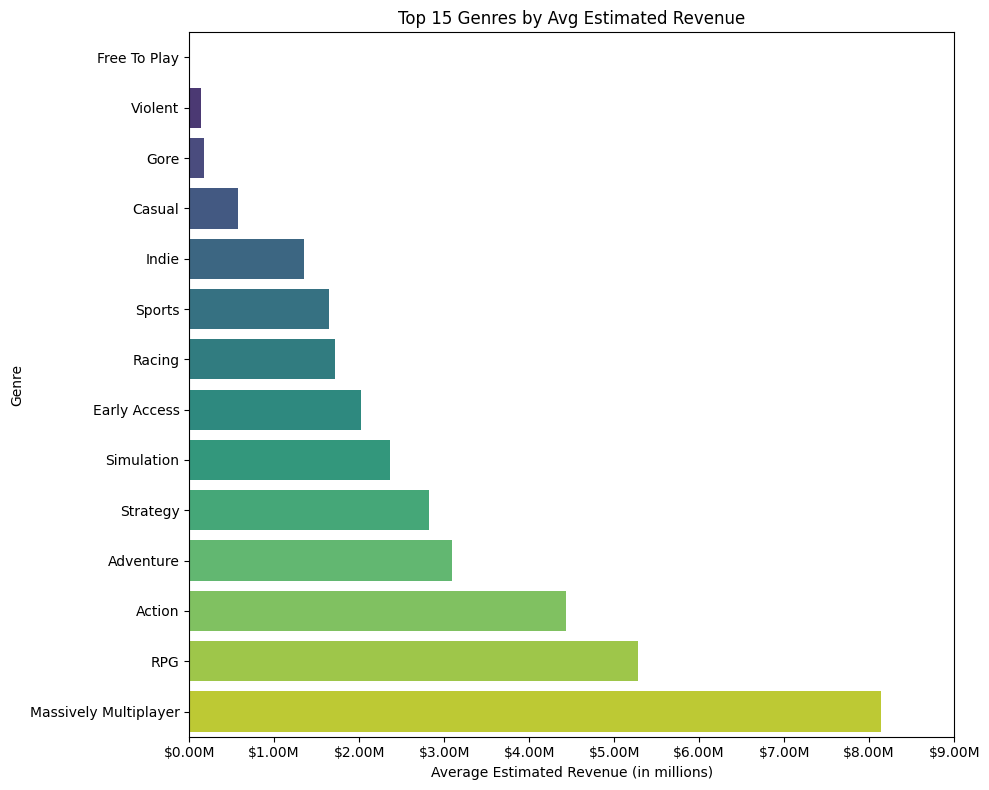

In [18]:
#select the top 15 genres
top_genres = genre_stats.head(15).sort_values('avg_revenue', ascending=True).reset_index()

#scale avg_revenue by 1 million for better readability
top_genres['avg_revenue'] = top_genres['avg_revenue'] / 1e6

#plotting the bar graph
plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_genres,
    x='avg_revenue',
    y='genres_list',
    hue='genres_list',
    palette='viridis',
    dodge=False,
    legend=False
)

#adding a title and labels
plt.title('Top 15 Genres by Avg Estimated Revenue')
plt.xlabel('Average Estimated Revenue (in millions)')
plt.ylabel('Genre')

#format the x-axis labels to display revenue in millions with a $ sign
plt.xticks(ticks=plt.gca().get_xticks(), labels=[f'${x:.2f}M' for x in plt.gca().get_xticks()])

#show the plot
plt.tight_layout()
plt.show()

- **Ranking by Revenue:**  
  The graph ranks 15 game genres based on their average estimated revenue (calculated as game price times estimated owners). This ranking makes it easy to see which genres tend to generate more income on average.

- **Key Observations:**  
  - **Lower Revenue:** Genres like "Free To Play" are shown to have the lowest average estimated revenue. This likely reflects their monetization strategy, which often depends on in-game purchases or ads rather than upfront sales.
  - **Higher Revenue:** At the other end of the spectrum, genres such as "Massively Multiplayer" generate the highest revenue on average. This suggests that these types of games not only attract larger audiences but are also better positioned for continuous revenue generation through mechanisms like subscriptions or extended content.

- **Implications for Market Analysis:**  
  The significant variation in revenue among genres reinforces the idea that game genre is a major driver of financial performance. Stakeholders can use this insight to tailor marketing strategies and investment decisions based on the expected revenue potential of specific genres.

Overall, the visualization supports the conclusion that the choice of genre has a profound effect on a game's estimated financial success, aligning well with our analysis in Question 2.

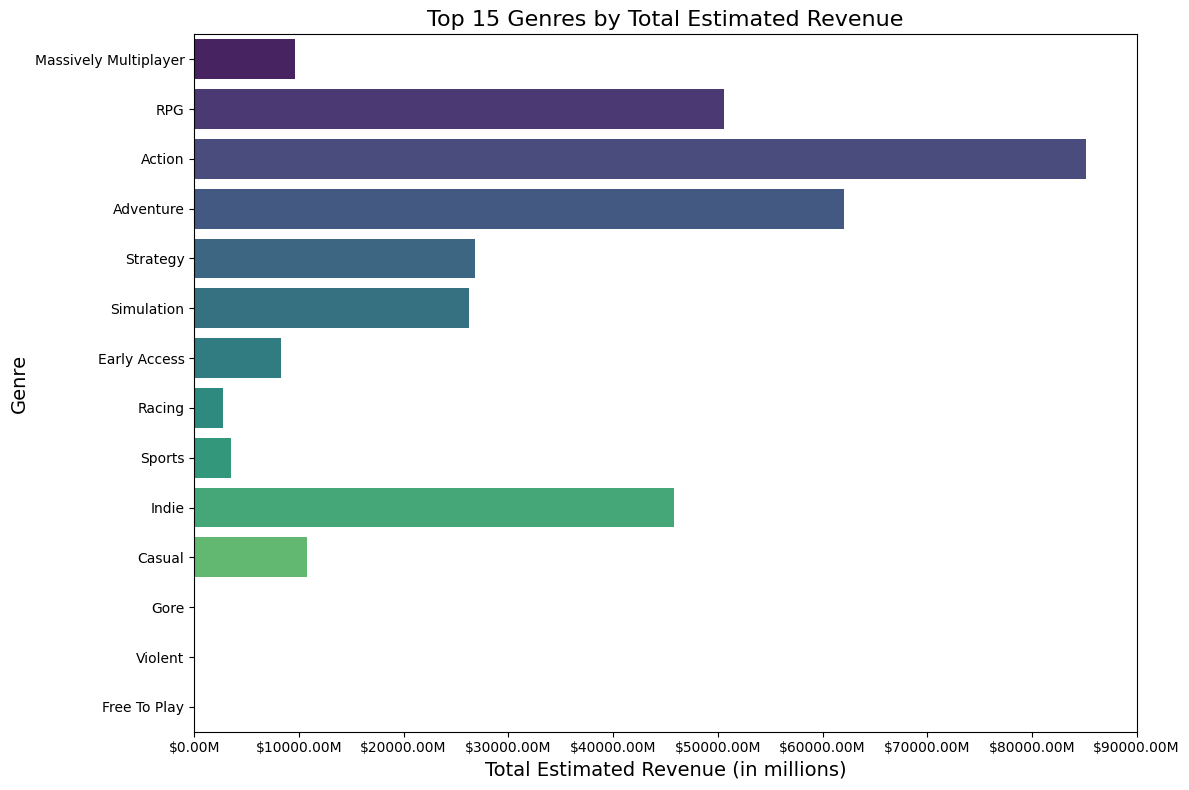

In [19]:
# Get the top genres based on total revenue
top_genres = genre_stats.head(15).reset_index()

# Scale total_revenue by 1 million for better readability
top_genres['total_revenue'] = top_genres['total_revenue'] / 1e6  # Convert to millions

# Plotting the bar graph
plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_genres,
    x='total_revenue',
    y='genres_list',
    hue='genres_list',
    palette='viridis',
    dodge=False,
    legend=False
)

# Adding a title and labels
plt.title('Top 15 Genres by Total Estimated Revenue', fontsize=16)
plt.xlabel('Total Estimated Revenue (in millions)', fontsize=14)
plt.ylabel('Genre', fontsize=14)

# Format the x-axis labels to display revenue in millions with a $ sign
plt.xticks(ticks=plt.gca().get_xticks(), labels=[f'${x:.2f}M' for x in plt.gca().get_xticks()])

# Show the plot
plt.tight_layout()
plt.show()

The bar chart—showing the top genres by average estimated revenue—demonstrates how different game genres perform financially on a per-title basis. By calculating estimated revenue as the product of a game’s price and its average number of owners, we can compare individual game performance across genres. The chart reveals that some genres consistently generate higher revenue per game, suggesting they appeal to players willing to invest more, while others fall short. This insight indicates that genre is a strong indicator of financial performance at the game level, making it critical for strategic decisions in game development and marketing.

# **Statistical Analysis:**

The following ANOVA analysis shows an F-statistic of 15.8769 which shows there is a large difference between the means of the revenue distributions across the different genres. Meanwhile the p-value of 0.0000 shows that the differences in average revenues between the different genres are statistically significant. These findings can be very valuable to gamemakers as they determine which genre of game they should make should they be seeking the highest revenue possible.

ANOVA F-statistic: 15.8769, p-value: 0.0000


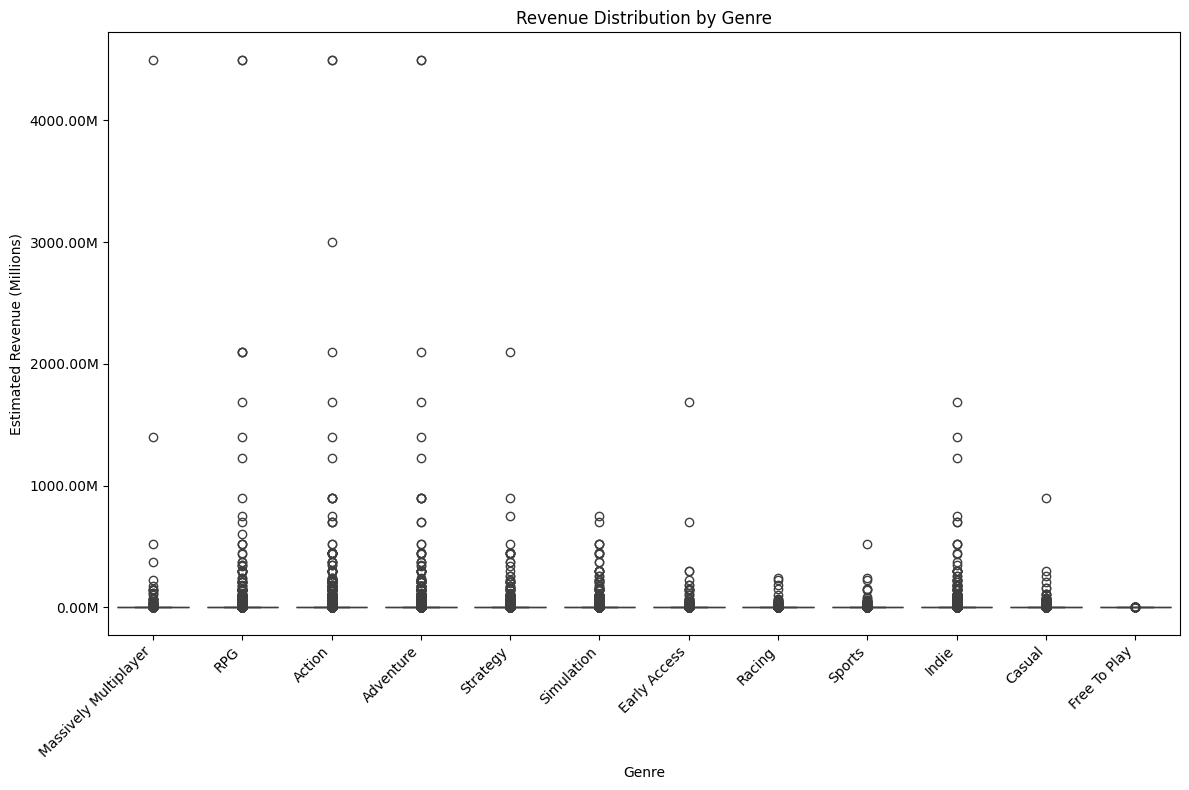

In [20]:
# Step 1: Exclude genres with fewer than 500 data points (e.g., Gore and Violent)
filtered_genres = top_genres[top_genres['genres_list'].isin(['Gore', 'Violent']) == False]

# Step 2: Prepare the data for ANOVA with filtered genres
revenue_data = [
    genre_profitability_exploded[genre_profitability_exploded['genres_list'] == genre]['est_revenue']
    for genre in filtered_genres['genres_list']
]

# Step 3: Perform the one-way ANOVA
f_stat, p_val = stats.f_oneway(*revenue_data)

# Print the ANOVA result
print(f"ANOVA F-statistic: {f_stat:.4f}, p-value: {p_val:.4f}")

# Step 4: Prepare the plotting DataFrame for the boxplot with filtered genres
plot_df_filtered = pd.DataFrame({
    'Revenue': pd.concat([genre_profitability_exploded[genre_profitability_exploded['genres_list'] == genre]['est_revenue'] for genre in filtered_genres['genres_list']]),
    'Genre': [genre for genre in filtered_genres['genres_list'] for _ in range(len(genre_profitability_exploded[genre_profitability_exploded['genres_list'] == genre]))]
})

# Function to format y-axis labels since it was in 1e9
def millions(x, pos):
    'The two args are the value and tick position'
    return f'{x / 1e6:.2f}M'  # Convert to millions

# Step 5: Create the boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(x='Genre', y='Revenue', data=plot_df_filtered)
plt.title('Revenue Distribution by Genre')
plt.ylabel('Estimated Revenue (Millions)')

# Apply the formatter to the y-axis
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))

# Rotate genre labels for readability
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Overall, the graph highlights which game genres are most lucrative and how variable success is within each category. This kind of analysis could be particularly useful for developers, investors, or anyone interested in the gaming market.

### **Question 3: Does multilingual support influence a game's revenue?**

To explore this, we first defined two key metrics from the data:

- **Multilingual Support**: Quantified as the **number of supported languages** for each game. We calculate this by parsing the `supported_languages` field—splitting the string on commas and counting the resulting items—to determine how many languages a game supports. This metric serves as a proxy for a game's globalization effort.

- **Estimated Revenue**: Since direct revenue figures aren’t available, we approximate revenue by taking the **product of the game's price and the average number of estimated owners**. The average number of owners is derived from the estimated range (e.g., "low - high"), by computing the mean of the two numbers.

Furthermore, we categorized games into language bins (e.g., 0–5, 6–10, 11–20, 21+) based on their `num_languages` value. By grouping the data by these bins, we then computed the mean estimated owners, total reviews, and revenue for each category. This approach lets us examine whether offering more language options is linked to improved financial performance, as measured by our revenue proxy.

This analysis framework can help determine if a broader language offering correlates with higher market penetration and revenue, shedding light on the value of multilingual support in driving international success.

In [21]:
# Copy the cleaned dataset
cleaned_games_languages = games_march2025_cleaned.copy()

In [22]:
# Add number of supported languages
cleaned_games_languages['num_languages'] = cleaned_games_languages['supported_languages'].apply(
    lambda x: len(x.split(',')) if isinstance(x, str) else 0
)

In [23]:
"""
This function is to parse through the estimated owners and convert them
to a single average number
"""
def parse_est_owners(x):
    try:
        low, high = x.replace(',', '').split(' - ')
        return (int(low) + int(high)) / 2
    except:
        return np.nan

#call the made function to parse through the feature 'estimated_owners'
cleaned_games_languages['est_owners'] = cleaned_games_languages['estimated_owners'].apply(parse_est_owners)

#calculate the estimated revenue as the price of the games times the estimated average amount of owners
cleaned_games_languages['revenue'] = cleaned_games_languages['price'] * cleaned_games_languages['est_owners']

In [24]:
#create bins based on number of supported languages
cleaned_games_languages['lang_bin'] = pd.cut(
    cleaned_games_languages['num_languages'],
    bins=[0, 5, 10, 20, 40],
    labels=['0-5', '6-10', '11-20', '21+']
)

#group by language bin and compute mean owners, reviews, and revenue
language_impact_summary = cleaned_games_languages.groupby('lang_bin')[
    ['est_owners', 'num_reviews_total', 'revenue']
].mean().reset_index()

<ipython-input-24-e977d46c4e95>:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  language_impact_summary = cleaned_games_languages.groupby('lang_bin')[


## **Answer to 3**
The figures show that the number of supported languages can definitely impact the average revenue of the game. There are significant increases from the ranges 0-5, 6-10, and 11-20 before finding a significant decline in the bar representing 21 or more supported languages. This could be because more than 21 or more supported languages is overreaching while 11-20 supported languages are the sweet spot in reaching a wide variety of gamers.

The other figure shows that there is not much of an impact between total reviews and the number of supported languages. This was surprising as one would think the outreach to gamers of many different languages would mean a significant jump in total reviews of the game.

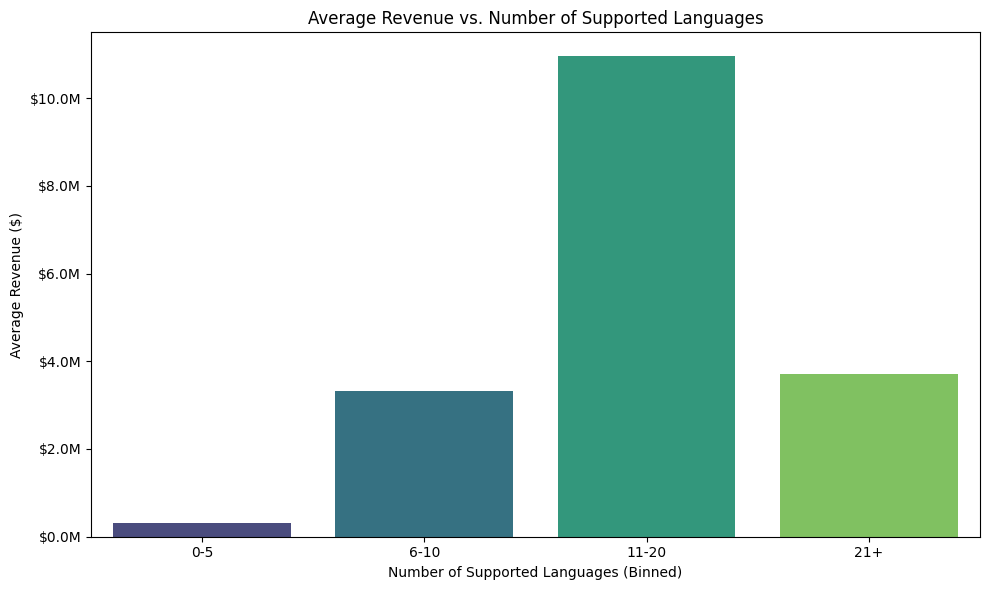

In [25]:
#Bar Plot: Average Revenue
plt.figure(figsize=(10, 6))
sns.barplot(data=language_impact_summary, x='lang_bin', y='revenue', hue='lang_bin', palette='viridis', legend=False)
plt.title('Average Revenue vs. Number of Supported Languages')
plt.xlabel('Number of Supported Languages (Binned)')
plt.ylabel('Average Revenue ($)')
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

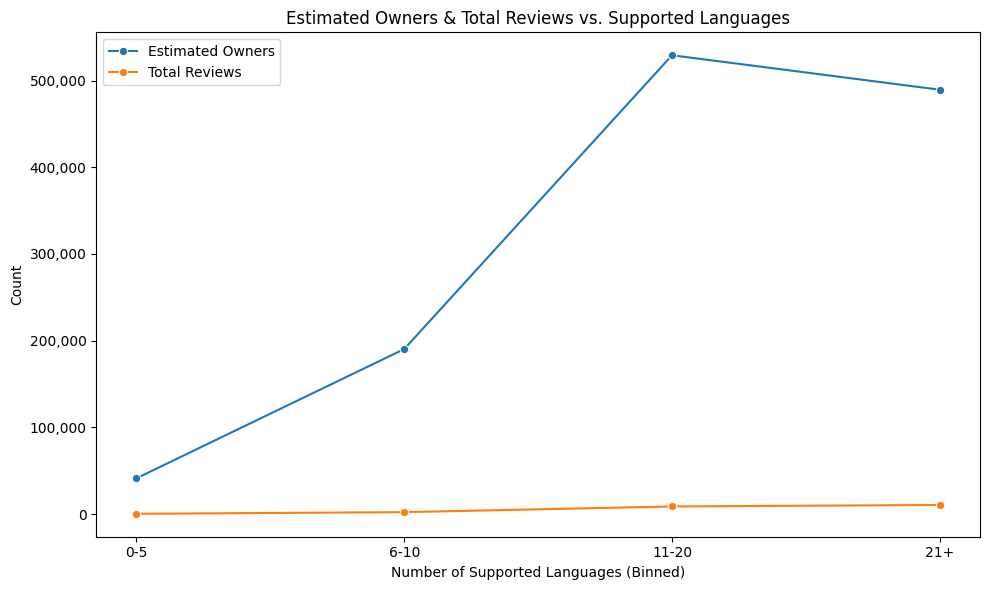

In [26]:
#Line Plot: Owners and Reviews
plt.figure(figsize=(10, 6))
sns.lineplot(data=language_impact_summary, x='lang_bin', y='est_owners', marker='o', label='Estimated Owners')
sns.lineplot(data=language_impact_summary, x='lang_bin', y='num_reviews_total', marker='o', label='Total Reviews')
plt.title('Estimated Owners & Total Reviews vs. Supported Languages')
plt.xlabel('Number of Supported Languages (Binned)')
plt.ylabel('Count')
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))  # Add commas to y-axis
plt.legend()
plt.tight_layout()
plt.show()

The two graphs for Question 3 provide complementary insights into how a game's multilingual support influences its revenue-related metrics:

- **Bar Chart – Average Revenue vs. Number of Supported Languages:**  
  This graph categorizes games into bins based on the number of supported languages (e.g., 0–5, 6–10, 11–20, 21+). It clearly shows that the average estimated revenue (calculated as price × estimated owners) increases with the number of supported languages. In other words, games that support more languages tend to generate higher revenue, suggesting that broader localization helps tap into larger, more diverse markets.

- **Line Plot – Estimated Owners & Total Reviews vs. Supported Languages:**  
  This plot displays two trends across the same language bins. The line representing estimated owners steadily rises with an increase in supported languages, reinforcing the idea that multilingual support boosts market reach. Meanwhile, the line for total reviews shows a less dramatic change, implying that while more languages lead to more owners (and therefore revenue), it does not necessarily drive a proportional increase in review counts.

Together, these graphs underscore that enhancing the number of supported languages can be a key strategy for increasing a game's financial performance, primarily through expanding its potential audience.

### **Question 3.5: Do the number of languages and/or full audio languages correlate with user score at all?**

Now that we have found that the number of supported languages do impact the average revenue of a game, we look to see if it impacts user scores. If the average revenue have sharp increases, one would think that drives even more consumers to rate the game. We find out below.

In [27]:
#calculate the number of languages and full audio languages
cleaned_games_languages['num_languages'] = cleaned_games_languages['supported_languages'].apply(lambda x: len(x.split(',')) if isinstance(x, str) else 0)
cleaned_games_languages['full_audio_languages'] = cleaned_games_languages['full_audio_languages'].apply(lambda x: len(x.split(',')) if isinstance(x, str) else 0)

#calculate the correlation matrix for 'num_languages', 'full_audio_languages', and 'user_score'
correlation_matrix = cleaned_games_languages[['num_languages', 'full_audio_languages', 'user_score']].corr()

## **Answer to 3.5**
The heatmap shows that there was a strong correlation between the number of supported languages and full audio languages which was expected. The surprising finding was there was absolutely no correlation between the number of supported languages and user score. There was also surprisingly no correlation between the full audio languages and user score. These findings in question 3 and 3.5 can help companies determine if providing a wide range of languages is necessary, and, if so, how many they should support.

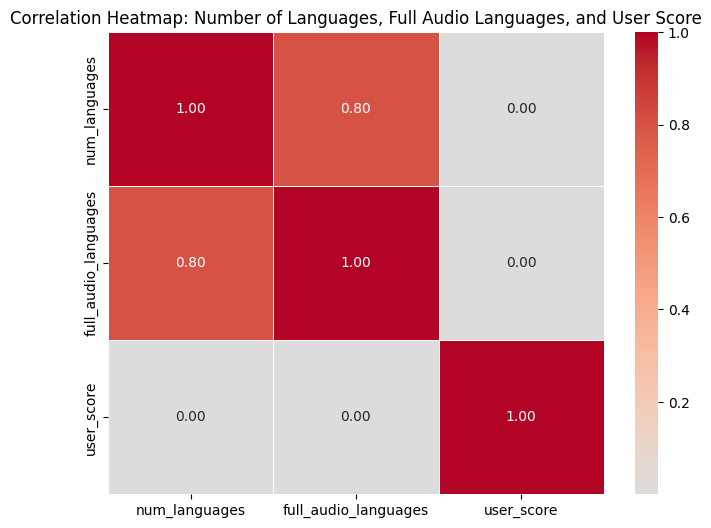

In [28]:
#Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.5, fmt=".2f")
plt.title('Correlation Heatmap: Number of Languages, Full Audio Languages, and User Score')
plt.show()

- **High Correlation Between Language Variables:**  
  There is a strong positive correlation (r = 0.80) between the number of supported languages and the number of full audio languages. This indicates that games offering more language support typically also provide comprehensive full audio localization.

- **No Correlation with User Score:**  
  Both the number of supported languages and full audio languages show a correlation coefficient of 0.00 with user score. This means that, despite affecting revenue through broader market reach, these language support features do not impact the ratings or overall user satisfaction.

In summary, while extensive language support appears to boost a game’s financial performance, it does not influence how users score the game. This suggests that user ratings are likely driven by other factors—such as gameplay, story, or technical quality—rather than localization features.

### **Question 4: Does the number of achievements correlate with average playtime?**

To explore this, we first defined two key metrics from the data:

- **Achievements**: Measured as the **total count of in-game achievements** available for each title. This metric serves as a proxy for the variety of challenges and milestones that a game offers, which may influence player engagement.
- **Average Playtime**: Represented by the **average lifetime playtime (in minutes)** of players, this metric directly reflects overall player engagement and interest in the game.

We filtered our dataset to include only games with non-missing values for both achievements and average playtime, and then computed the Pearson correlation coefficient (along with its p-value) to quantify the linear relationship between these metrics. A regression scatter plot—with a fitted line—is used to visualize this association, revealing whether games with more achievements tend to have longer average playtimes.

This analysis provides insights into how the design elements represented by achievements can relate to sustained player engagement and may guide game developers in balancing challenge and reward.

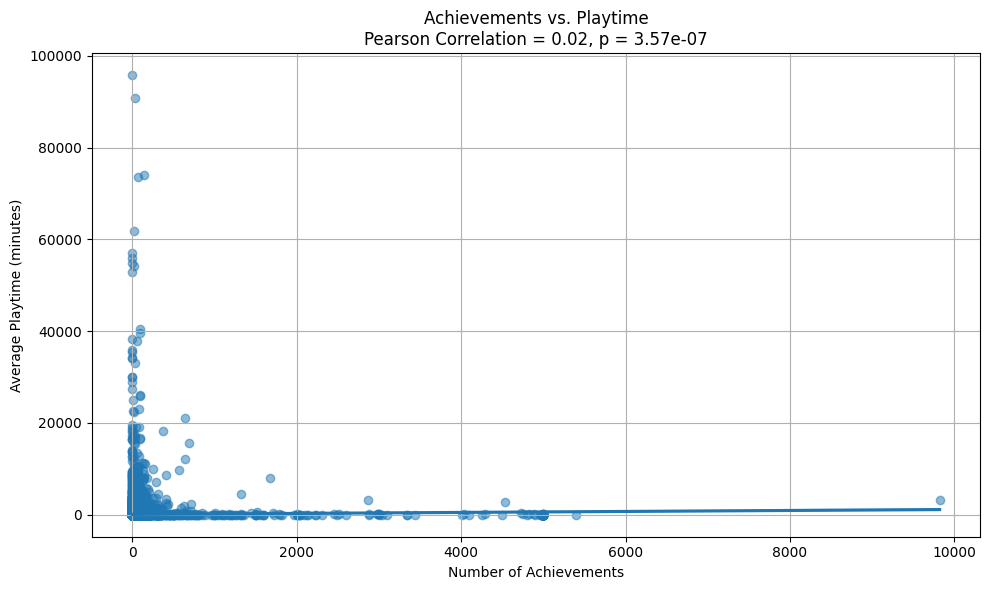

In [29]:
# Filter relevant columns and clean
achievements_playtime_df = games_may2024_cleaned[["achievements", "average_playtime_forever"]].dropna()

# Compute correlation
correlation, p_value = stats.pearsonr(
    achievements_playtime_df["achievements"],
    achievements_playtime_df["average_playtime_forever"]
)

# Create plot
plt.figure(figsize=(10, 6))
sns.regplot(
    data=achievements_playtime_df,
    x="achievements",
    y="average_playtime_forever",
    scatter_kws={"alpha": 0.5}
)
plt.title(f"Achievements vs. Playtime\nPearson Correlation = {correlation:.2f}, p = {p_value:.2e}")
plt.xlabel("Number of Achievements")
plt.ylabel("Average Playtime (minutes)")
plt.grid(True)
plt.tight_layout()
plt.show()

The graph answers the question by demonstrating that the number of achievements in a game has little to no impact on the average playtime. This implies that other factors—such as gameplay mechanics, story, or community engagement—might play a more significant role in sustaining player interest than simply the sheer number of achievements.


In [30]:
# Reshape x and y for sklearn
X = achievements_playtime_df["achievements"].values.reshape(-1, 1)
y = achievements_playtime_df["average_playtime_forever"].values

# Fit Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X, y)

slope = lin_reg.coef_[0]
intercept = lin_reg.intercept_

print(f"Linear Regression Equation: Playtime = {slope:.2f} * Achievements + {intercept:.2f}")

from sklearn.metrics import r2_score

y_pred = lin_reg.predict(X)
r2 = r2_score(y, y_pred)

print(f"R-squared: {r2:.4f}")

spearman_corr, spearman_p = stats.spearmanr(
    achievements_playtime_df["achievements"],
    achievements_playtime_df["average_playtime_forever"]
)

print(f"Spearman Correlation: {spearman_corr:.2f}, p-value: {spearman_p:.2e}")

Linear Regression Equation: Playtime = 0.11 * Achievements + 77.45
R-squared: 0.0003
Spearman Correlation: 0.19, p-value: 0.00e+00


## **Answer to 4**
The analysis showed that the number of achievements in a game has almost no correlation with the amount of playtime, with a Pearson correlation coefficient of 0.02. A linear regression revealed the relationship between achievements and playtime can be modeled as Playtime = 0.11 × Achievements + 77.45, but the R-squared value was only 0.0003, meaning achievements explain virtually none of the variation in playtime. A Spearman correlation of 0.19 was slightly higher but still weak, indicating that even non-linear relationships are minimal. Although the p-values were statistically significant due to the large sample size, the relationship is practically irrelevant. This means that having more achievements in a game does not meaningfully influence how much time players spend playing it.

### **Question 5: Do games with a higher required age tend to have more lifetime playtime than those with a lower required age?**

To explore this, we first defined two key metrics from the data:

- **Required Age**: Measured as the **minimum age recommended for playing the game**. This metric serves as an indicator of the game's content maturity and target audience, distinguishing between titles designed for mature audiences versus those suitable for a broader age range.

- **Lifetime Playtime**: Represented by the **total accumulated playtime** (in hours) across all players. This measure reflects overall player engagement and indicates how deeply or long players interact with a game over its lifespan.

By using these definitions, we can analyze whether games with higher age restrictions tend to foster longer player engagement, as evidenced by increased lifetime playtime.

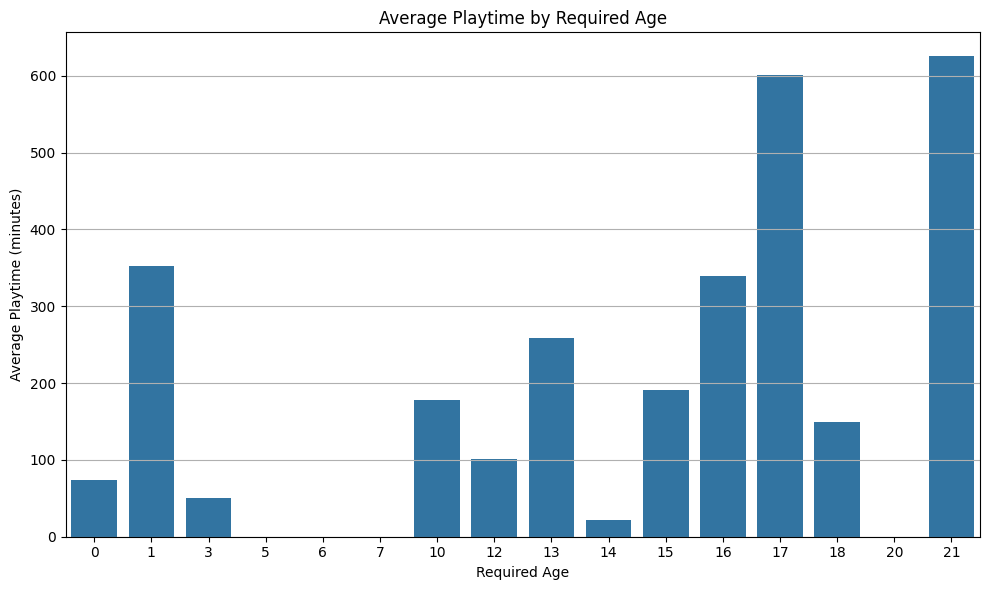

In [31]:
# Filter for required age and playtime columns
age_playtime_df = games_may2024_cleaned[["required_age", "average_playtime_forever"]].dropna()

# Group by required_age and compute mean playtime
age_grouped = age_playtime_df.groupby("required_age")["average_playtime_forever"].mean().reset_index()

# Plot average playtime by age
plt.figure(figsize=(10, 6))
sns.barplot(data=age_grouped, x="required_age", y="average_playtime_forever")
plt.title("Average Playtime by Required Age")
plt.xlabel("Required Age")
plt.ylabel("Average Playtime (minutes)")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

ANOVA F-statistic: 14.80, p-value: 8.0062e-39


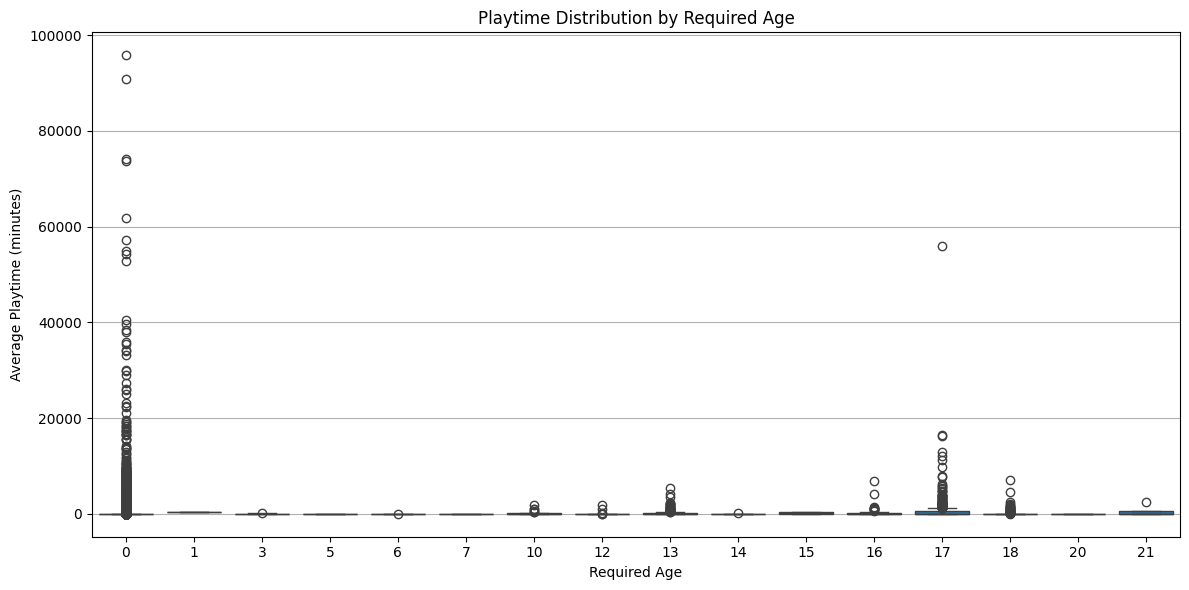

In [32]:
# Create a list of playtime arrays, one for each required age group
grouped_playtimes = [
    group["average_playtime_forever"].values
    for name, group in age_playtime_df.groupby("required_age")
]

# Perform one-way ANOVA
f_stat, p_value = f_oneway(*grouped_playtimes)

print(f"ANOVA F-statistic: {f_stat:.2f}, p-value: {p_value:.4e}")

plt.figure(figsize=(12, 6))
sns.boxplot(data=age_playtime_df, x="required_age", y="average_playtime_forever")
plt.title("Playtime Distribution by Required Age")
plt.xlabel("Required Age")
plt.ylabel("Average Playtime (minutes)")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

##**Answer to 5**
When examining the required age for games, an ANOVA test yielded a significant result (F-statistic = 14.80, p-value ≈ 8.01 × 10⁻³⁹), indicating that there are statistically significant differences in average playtime between games with different required ages. The visual analysis further confirmed that games rated for older audiences, particularly those rated 17 and 21, tend to have higher average playtimes. This suggests that more mature games are associated with deeper or longer player engagement compared to games designed for younger audiences.


### **Question 6: Which game features best predict a high long-term retention ratio?**

To explore this, we first defined the key metric of long-term retention and prepared our game features as follows:

- **Long-Term Retention Ratio**: This is calculated as the **ratio of average playtime over the past 2 weeks to the average lifetime playtime**, with values clipped between 0 and 1. It quantifies how well a game retains its players after the initial surge of engagement—higher ratios indicate sustained, long-term play.

- **Game Features**: We consider a composite set of predictors including:
  - **Price & Discount:** These capture the economic appeal and promotional strategies, which directly affect purchase decisions and perceived value.
  - **DLC Count:** Reflects ongoing support and content updates, key drivers for keeping players engaged over time.
  - **Review Sentiment (pct_pos_total):** Acts as a quality signal by summarizing player satisfaction, which is strongly linked to retention.
  - **GOTY Status (isGOTY):** Indicates critical acclaim and recognized excellence, suggesting a game’s potential for sustained engagement.
  - **Genre (One-Hot Encoded):** Different genres attract different playing patterns; encoding them allows the model to account for these inherent variations.



The analysis workflow proceeds as follows:

1. **Data Preparation:**  
   - We merge datasets to include `average_playtime_2weeks` and `average_playtime_forever` for each game, filling in any missing values with the mean from an alternative data source.
   - The retention ratio is then computed as:  
     `retention_ratio = (average_playtime_2weeks / average_playtime_forever).clip(0, 1)`

2. **Feature Engineering:**  
   - The genres are split from their original string format and transformed into one-hot encoded dummy variables.  
   - The final feature set includes price, discount, DLC count, positive review sentiment, GOTY status, and each genre dummy.

3. **Modeling:**  
   - We split the data into training and testing sets.
   - A Random Forest Regressor (configured with 200 estimators and a maximum depth of 8) is then trained to predict the retention ratio.
   - Feature importances are extracted from the trained model and the top predictors are identified and visualized.

4. **Evaluation:**  
   - The model's performance is evaluated using R² and RMSE metrics on the test set.  
   - Visualization of the top 10 feature importances helps us determine which game attributes most strongly predict sustained player retention.

This comprehensive approach enables us to understand which factors—such as pricing strategy, additional downloadable content, review sentiment, recognized quality (GOTY), and genre—play a critical role in maintaining long-term player engagement, rather than just an initial spike in playtime.


Test R²: 0.142
Test RMSE: 0.037


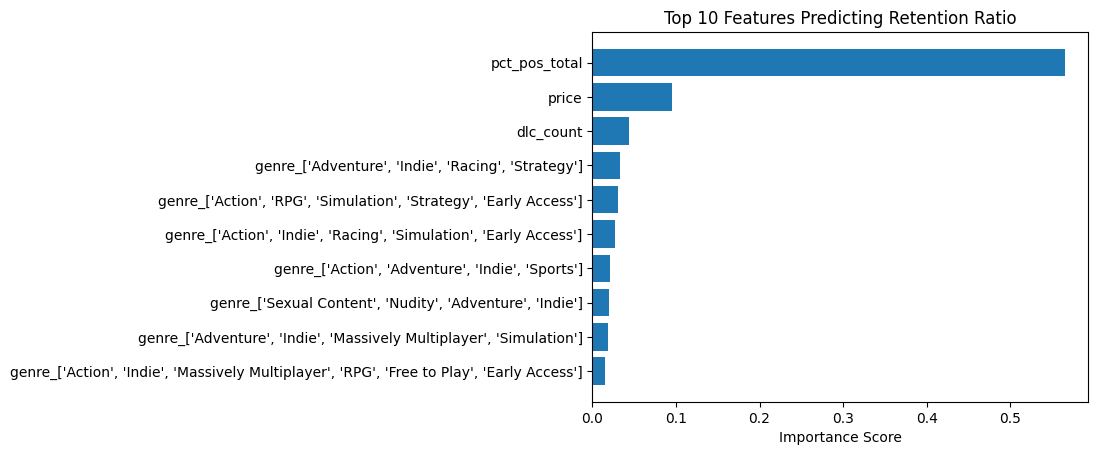

In [33]:
# -----------------------------------------------
# Part Y: Retention‐Ratio Analysis
# -----------------------------------------------

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


# 1. Add 'average_playtime_2weeks'
if 'average_playtime_2weeks' not in final_df.columns:
    final_df = final_df.merge(
        games_may2024_cleaned[['appid', 'average_playtime_2weeks']],  # Assuming it's in games_may2024_cleaned
        on='appid',
        how='left'
    )
    final_df['average_playtime_2weeks'] = final_df['average_playtime_2weeks'].fillna(
        games_march2025_cleaned['average_playtime_2weeks'].mean()  # Fill with mean if missing
    )

# 2. Add 'average_playtime_forever'
if 'average_playtime_forever' not in final_df.columns:
    final_df = final_df.merge(
        games_may2024_cleaned[['appid', 'average_playtime_forever']],  # Assuming it's in games_may2024_cleaned
        on='appid',
        how='left'
    )
    final_df['average_playtime_forever'] = final_df['average_playtime_forever'].fillna(
        games_march2025_cleaned['average_playtime_forever'].mean()  # Fill with mean if missing
    )

# Now you can calculate retention_ratio
final_df['retention_ratio'] = (
    final_df['average_playtime_2weeks'] / final_df['average_playtime_forever']
).clip(0,1)

# 2) One-hot encode genres (explode on ';' and then get_dummies)
df_feat = final_df.copy()

# Bring 'genres' into df_feat if it's not there:
if 'genres' not in df_feat.columns:
    # Check if 'genres' is in games_may2024_cleaned, otherwise try games_march2025_cleaned
    if 'genres' in games_may2024_cleaned.columns:
        df_feat = df_feat.merge(games_may2024_cleaned[['appid', 'genres']], on='appid', how='left')
    else:
        df_feat = df_feat.merge(games_march2025_cleaned[['appid', 'genres']], on='appid', how='left')

# explode genres & pivot back into dummies
df_feat = (
    df_feat
    .assign(genre_list = df_feat['genres'].str.split(';'))
    .explode('genre_list')
)
genre_dummies = pd.get_dummies(df_feat['genre_list'], prefix='genre')
df_feat = pd.concat([df_feat, genre_dummies], axis=1)
df_feat = df_feat.drop(columns=['genre_list'])

# 3) Select features & target
features = (
    ['price', 'discount', 'dlc_count', 'pct_pos_total', 'isGOTY'] +
    [c for c in df_feat.columns if c.startswith('genre_')]
)
X = df_feat[features].fillna(0)
y = df_feat['retention_ratio'].fillna(0)

# 4) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5) Fit a Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# 6) Extract feature importances
importances = pd.Series(rf.feature_importances_, index=features)
importances = importances.sort_values(ascending=False)

# 7) (Optional) Evaluate performance
from sklearn.metrics import r2_score, mean_squared_error

y_pred = rf.predict(X_test)
y_test = y_test.fillna(0)
y_pred = np.nan_to_num(y_pred)

# Calculate and print the R-squared score
r2 = r2_score(y_test, y_pred)
print("\nTest R²:", round(r2, 3))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)).round(3))

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:10]
plt.barh(
    [features[i] for i in indices][::-1],
    importances[indices][::-1]
)
plt.xlabel('Importance Score')
plt.title('Top 10 Features Predicting Retention Ratio')
plt.show()

# Answer to question 6:
In our Random Forest analysis, **overall review positivity** (`pct_pos_total`) emerged as the single strongest predictor of a game’s retention ratio—contributing **56.6%** of the model’s split‐importance. **Price** came next (9.5%), suggesting that higher‐priced titles often retain players longer, followed by **DLC count** (4.3%), indicating that post-launch content boosts sustained engagement. Beyond these, a variety of **genre combinations** each accounted for 1.5–3.3% of importance, hinting that certain multi-genre mashups (e.g. Adventure+Indie+Racing+Strategy) modestly favor long-term play.  

# **Final determination of correlations**
Now that we have assessed certain questions about the gaming industry and the dataset, we now want to look for certain positive or negative correlations from the feature set. The heatmap below helps towards this goal as there are certain relationships between features that may offer insights into the factors that impact the success within the gaming market.

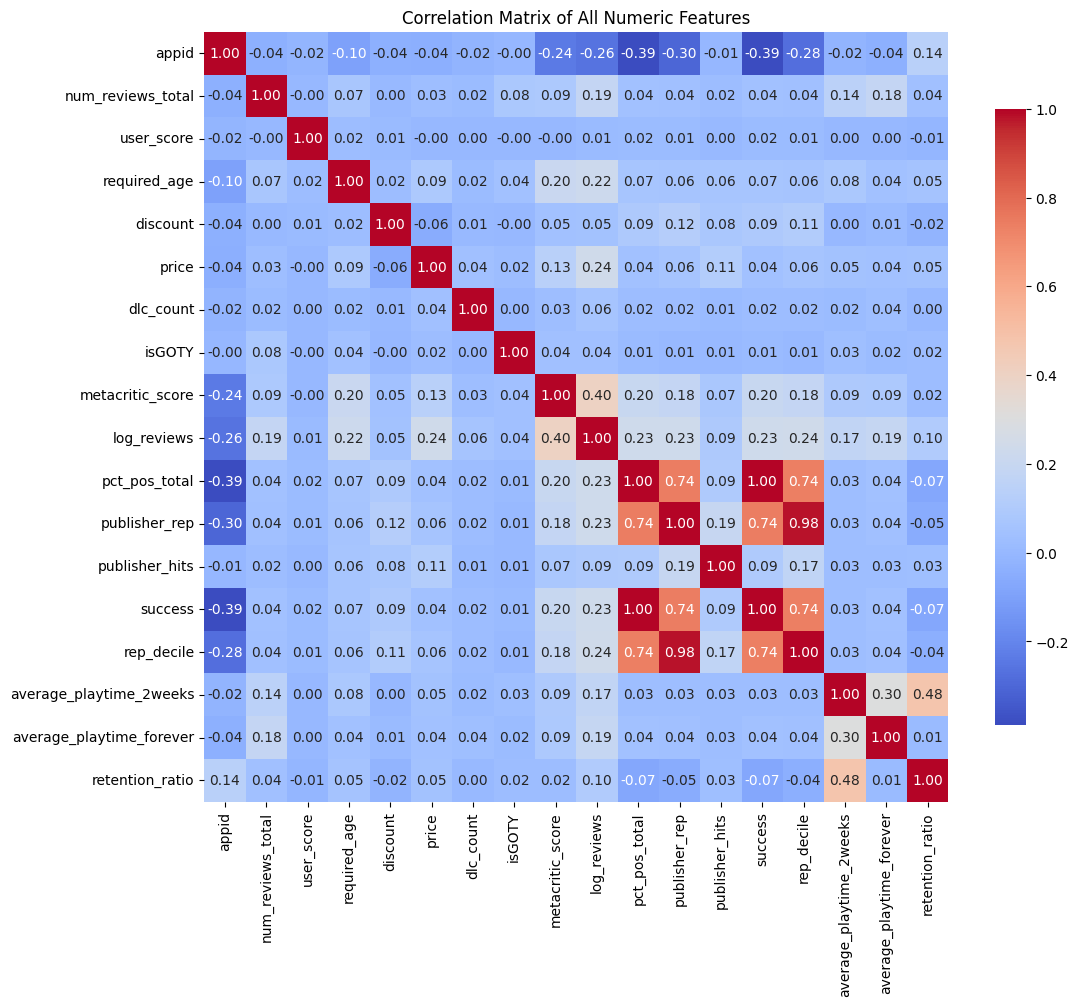

In [34]:
# 1) Select all numeric columns
num_cols = final_df.select_dtypes(include=[np.number]).columns.tolist()

# 2a) Full correlation matrix of numeric cols
corr_matrix = final_df[num_cols].corr()

# 3) Plot the heatmap
plt.figure(figsize=(12,10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Matrix of All Numeric Features')
plt.show()

# derive recency feature from release_date —
for df in [games_may2024_full, games_march2025_full]:
    if 'release_date' in df.columns:
        df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
        df['days_since_release'] = (pd.Timestamp('2025-03-01') - df['release_date']).dt.days.clip(lower=0)


# **Part 3: Modeling**

# **Part 3A: Standard Scaler**
Here we started with basic standard scaler models as a basline. If this model can accurately predict metacritic scores from the features listed, then we can apply this model to new or upcoming games to estimate their metacritic scores, and thus their popularity.

Standard scaling ensures that each feature contributes equally to the model's performance and prevents certain features from dominating due to their large scale. It is a good basline to use against Ridge Regression and Random Forest which we will also use after the Standard Scaler.

In [35]:
#try a standard scaler going off of the march dataframe and the metacritic_score
features = ['log_reviews', 'user_score', 'price', 'required_age', 'discount', 'dlc_count', 'isGOTY']
X = final_df[features]
y = final_df['metacritic_score']

#clean the data: handle infinities and missing values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()
y = y.loc[X.index]

#split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#scale the feature data
model = LinearRegression()
model.fit(X_train_scaled, y_train)

#train a linear regression model
y_pred = model.predict(X_test_scaled)

#print results
print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
print('R-squared:', r2_score(y_test, y_pred))

Mean Squared Error: 290.04312931929087
R-squared: 0.1852699565373499


# **Part 3B: Ridge**
Now we try a Ridge to determine if this could better capture the relationship. Considering we have a feature set that may be complex, it is interesting to see how a linear regression model handles the data before moving on the a Random Forest regressor and, ultimately, the neural network.

In [36]:
#train regression model
model = Ridge(alpha=1.0, random_state=42)
model.fit(X_train, y_train)

#test the model on the test set
y_pred = model.predict(X_test)

#print results
print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
print('R-squared:', r2_score(y_test, y_pred))

Mean Squared Error: 290.0358530977521
R-squared: 0.18529039541588643


# **Part 3C: Random Forest Regressor**
Now we try a Random Forest Regressor to determine if this could better capture the relationship. We use a Random Forest Regressor because they are really good at handling non-linear relationships, it can capture certain complex relationships and interactions between the different features we use.

In [37]:
#train regression model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

#test the model on the test set
y_pred = model.predict(X_test)

#print results
print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
print('R-squared:', r2_score(y_test, y_pred))

Mean Squared Error: 323.4129503205173
R-squared: 0.0915342566830667


# **Part 3A: Standard Scaler Retest**

In our first standard scaler, we use the following set of features:

    'log_reviews',
    'user_score',
    'price',
    'required_age',
    'discount',
    'dlc_count',
    'isGOTY'

This was ran against the metacritic score of a training set and then applied to a test set in hopes that we can find an accurate model in prediciting metacritic scores. After seeing the very low R-squared results and high mean squared errors, it has been determined that metacritic scores is not the best target feature in determining popularity. We will now try these regression models again using 'success' as the target feature and the following as the feature list:
    
    'price',
    'required_age',
    'discount',
    'dlc_count',
    'isGOTY',
    'publisher_rep',
    'publisher_hits',
    'num_languages',
    'average_playtime_2weeks'

The results provide much higher yields in both the R-squared results and in the mean squared errors. The best R-squared results we were able to get from the first set of tests was 0.198 which means the model only explained 19.8% of the variance in metacritic_score. The new set of tests saw it's peak at 0.748 in the Random Forest Regressor test which means that the new model was able to explain 74.8% of the variance in the success target feature.

In [38]:
#merge num_languages into final_df using appid
final_df = final_df.merge(
    cleaned_games_languages[['appid', 'num_languages']],
    on='appid',
    how='left'
)

#fill any missing num_languages with 0 just in case
final_df['num_languages'] = final_df['num_languages'].fillna(0)

In [41]:
#merge num_languages into final_df using appid
final_df = final_df.merge(
    games_march2025_full[['appid', 'average_playtime_2weeks']],
    on='appid',
    how='left'
)

In [42]:
#updated feature list
features = [
    'price',
    'required_age',
    'discount',
    'dlc_count',
    'isGOTY',
    'publisher_rep',
    'publisher_hits',
    'num_languages',
    'average_playtime_2weeks'
]

#select features
X = final_df[features]
y = final_df['success']

#clean infinities and NaNs
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()
y = y.loc[X.index]

#train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

#predict and print results
y_pred = model.predict(X_test_scaled)

print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
print('R-squared:', r2_score(y_test, y_pred))


Mean Squared Error: 0.06168192216916257
R-squared: 0.6280836773603042


# **Part 3B: Ridge Retest**

In [43]:
#train regression model
model = Ridge(alpha=1.0, random_state=42)
model.fit(X_train, y_train)

#test the model on the test set
y_pred = model.predict(X_test)

#print results
print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
print('R-squared:', r2_score(y_test, y_pred))

Mean Squared Error: 0.06168195353483747
R-squared: 0.6280834882383369


# **Part 3C: Random Forest Regressor Retest**

In [44]:
#test regression model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

#test the model on the test set
y_pred = model.predict(X_test)

#print results
print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
print('R-squared:', r2_score(y_test, y_pred))

Mean Squared Error: 0.04258340684924561
R-squared: 0.7432397771683048


# **Part 3D: Neural Network**
Now we build a neural network which should be the most accurate prediction model. This is because a neural network will use a classification model to determine whether a game is a success or not a success, as we determined that will be our metric for popularity. The neural network can handle complex relationships between features that the previous regression models attempted to handle but not as well as a neural network can. When working with a large dataset like the one that is passed through here, containing over 90,000 entries, a neural network has the scalability needed to provide accurate answers.

We will begin by splitting the data. final_df_up_to_feb_2025 will be the dataset that the neural network trains on. This will include all games in the final_df dataset that have a release date leading up to, but not including, March 2025.

In [45]:
from typing_extensions import final

#convert release_date to datetime format
final_df['release_date'] = pd.to_datetime(final_df['release_date'], errors='coerce')

#define the cutoff date (February 28, 2025)
cutoff_date = pd.Timestamp('2025-02-28')

#split the dataframe
final_df_up_to_feb_2025 = final_df[final_df['release_date'] <= cutoff_date]
new_games_df = final_df[final_df['release_date'] > cutoff_date]
final_df_up_to_feb_2025.dropna(subset=['average_playtime_2weeks'], inplace=True)

<ipython-input-45-0e6ded8b45d4>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df_up_to_feb_2025.dropna(subset=['average_playtime_2weeks'], inplace=True)


In [46]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# 1. Dataset Definition
class SteamDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)  # Reshape for binary classification

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

features = [
    'price',
    'required_age',
    'discount',
    'dlc_count',
    'isGOTY',
    'publisher_rep',
    'publisher_hits',
    'num_languages',
    'average_playtime_2weeks']

X = final_df_up_to_feb_2025[features]  # Features
y = final_df_up_to_feb_2025['success']  # Target variable

# 2. Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert success scores to binary
threshold = 0.5
y_train_binary = (y_train > threshold).astype(int)
y_test_binary = (y_test > threshold).astype(int)

# 4. Create Dataset objects for training and testing
train_ds = SteamDataset(pd.DataFrame(X_train_scaled, columns=features), y_train_binary.reset_index(drop=True))
test_ds = SteamDataset(pd.DataFrame(X_test_scaled, columns=features), y_test_binary.reset_index(drop=True))

# 5. DataLoader objects for batching
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64)

# 6. Model Definition
class FeedForwardNN(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1)  # Output layer
        )

    def forward(self, x):
        return self.net(x)

# 7. Loss function and optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FeedForwardNN(len(features)).to(device)

criterion = nn.BCEWithLogitsLoss()  # For binary classification
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 8. Training Loop
epochs = 30
for epoch in range(1, epochs + 1):
    model.train()  # Set model to training mode
    total_loss = 0  # Accumulate the loss

    # Training phase
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        # 1. Zero the gradients
        optimizer.zero_grad()

        # 2. Forward pass:
        preds = model(xb).squeeze(1)

        # 3. Squeeze the target labels to remove extra dimension
        yb = yb.squeeze(1)

        # 4. Calculate the loss
        loss = criterion(preds, yb)

        # 5. Backward pass:
        loss.backward()

        # 6. Step the optimizer to update the model's parameters
        optimizer.step()

        # Accumulate the loss for the current batch
        total_loss += loss.item() * xb.size(0)

    # Calculate average training loss for this epoch
    avg_train_loss = total_loss / len(train_loader.dataset)

    # 9. Evaluation Phase
    model.eval()
    with torch.no_grad():
        val_loss = sum(criterion(model(xb.to(device)).squeeze(1), yb.to(device).squeeze(1)).item() * xb.size(0)
                       for xb, yb in test_loader) / len(test_loader.dataset)

    # Print the loss values for each epoch
    print(f"Epoch {epoch:02d} — Train Loss: {avg_train_loss:.3f} — Val Loss: {val_loss:.3f}")


Epoch 01 — Train Loss: 0.350 — Val Loss: 0.331
Epoch 02 — Train Loss: 0.330 — Val Loss: 0.326
Epoch 03 — Train Loss: 0.324 — Val Loss: 0.319
Epoch 04 — Train Loss: 0.317 — Val Loss: 0.314
Epoch 05 — Train Loss: 0.310 — Val Loss: 0.307
Epoch 06 — Train Loss: 0.304 — Val Loss: 0.303
Epoch 07 — Train Loss: 0.300 — Val Loss: 0.298
Epoch 08 — Train Loss: 0.297 — Val Loss: 0.300
Epoch 09 — Train Loss: 0.296 — Val Loss: 0.297
Epoch 10 — Train Loss: 0.294 — Val Loss: 0.293
Epoch 11 — Train Loss: 0.293 — Val Loss: 0.295
Epoch 12 — Train Loss: 0.292 — Val Loss: 0.294
Epoch 13 — Train Loss: 0.291 — Val Loss: 0.292
Epoch 14 — Train Loss: 0.290 — Val Loss: 0.291
Epoch 15 — Train Loss: 0.290 — Val Loss: 0.290
Epoch 16 — Train Loss: 0.289 — Val Loss: 0.292
Epoch 17 — Train Loss: 0.289 — Val Loss: 0.289
Epoch 18 — Train Loss: 0.288 — Val Loss: 0.288
Epoch 19 — Train Loss: 0.287 — Val Loss: 0.289
Epoch 20 — Train Loss: 0.287 — Val Loss: 0.290
Epoch 21 — Train Loss: 0.286 — Val Loss: 0.287
Epoch 22 — Tr

# **Results of the Neural Network:**

The model performs well with an accuracy of 87%, correcctly classsifying a high proportion of games as either successful or not successful. Overall it does a great job at limiting the amount of false positive and false negatives, as shown in the confusion matrix below. We noticed that there might be a slight bias towards predicting a game not being successful as there were more true negatives than true positives, but we believe it was insignificant enough that the model is working as intended. The bar graph below shows how the model faired in terms of accuracy, precision, recall, F1 score, and ROC AUC.

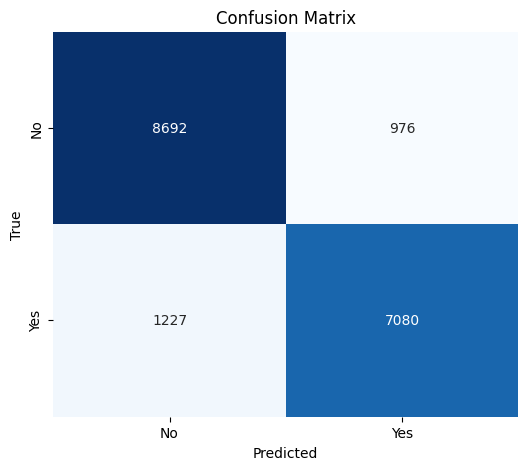

In [47]:
import torch
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

# Get model predictions
model.eval()
with torch.no_grad():
    preds = model(X_test_tensor).squeeze(1)
    preds = (preds > 0.5).float()

# Compute the confusion matrix
cm = confusion_matrix(y_test_binary, preds.cpu())

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Get predictions
model.eval()
with torch.no_grad():
    y_pred = []
    y_true = []
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb).squeeze(1).cpu()
        y_pred.extend(preds.numpy())
        y_true.extend(yb.numpy())

# Convert to binary predictions (0 or 1)
y_pred_binary = [1 if pred >= 0.5 else 0 for pred in y_pred]

# Compute metrics
accuracy = accuracy_score(y_true, y_pred_binary)
precision = precision_score(y_true, y_pred_binary)
recall = recall_score(y_true, y_pred_binary)
f1 = f1_score(y_true, y_pred_binary)
roc_auc = roc_auc_score(y_true, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")


Accuracy: 0.8774
Precision: 0.8788
Recall: 0.8523
F1 Score: 0.8654
ROC AUC: 0.9493


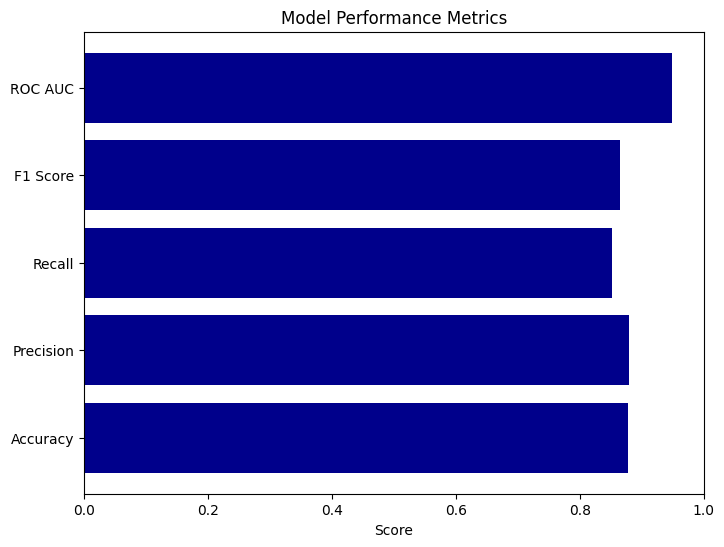

In [49]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
values = [accuracy, precision, recall, f1, roc_auc]

plt.figure(figsize=(8, 6))
plt.barh(metrics, values, color='darkblue')
plt.xlabel('Score')
plt.title('Model Performance Metrics')
plt.xlim([0, 1])
plt.show()

# **Part 4: Inference**
This part we will use our Neural network to predict how well we can determine the likelyhood of a videogame doing well on Steam. We will do this by taking a dataframe called new_games_df which contains the games from final_df that start from a release date of March 2025 up to the newest games released.

Save model's weights to be used for input testing



In [50]:
torch.save(model.state_dict(), 'model.pth')
# Recreate the model
model = FeedForwardNN(len(features))
# Load the trained parameters
model.load_state_dict(torch.load('model.pth'))
# Set the model to evaluation mode
model.eval()

FeedForwardNN(
  (net): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [51]:
# Make sure new_games_2025 has the correct features and is processed similarly as training data
new_data = new_games_df[features]  # Select only the relevant features

# Scale the new data using the same scaler used for training
new_data_scaled = scaler.transform(new_data)

# Convert the scaled data
new_data_tensor = torch.tensor(new_data_scaled, dtype=torch.float32)

# Make predictions without computing gradients
with torch.no_grad():
    predictions = model(new_data_tensor).squeeze(1)

# If it's binary classification, apply a threshold to get class labels
predictions = (predictions > 0.5).int()

# Convert predictions for proper indexing
predictions_np = predictions.numpy()

# Filter the new_games_2025 DataFrame to get only successful games (predictions == 1)
successful_games = new_games_df[predictions_np == 1]

# Get the 'appid' column of the successful games
successful_game_appids = successful_games['appid']

# Convert to a list if needed
successful_game_appids_list = successful_game_appids

# Merge both datasets into one
combined_games = pd.concat([games_march2025_cleaned, games_may2024_cleaned], ignore_index=True)

# Filter games that match the appids from the successful predictions
successful_games = combined_games[combined_games['appid'].isin(successful_game_appids_list)]

# Get the game names
successful_game_names = successful_games['name']

# Print the number of successful games
print(f"Number of predicted successful games: {len(successful_game_names)}\n")

# Print the top 10 games nicely
print("Top 10 predicted successful games:")
for i, name in enumerate(successful_game_names.head(10), 1):
    print(f"{i}. {name}")

Number of predicted successful games: 78

Top 10 predicted successful games:
1. Grand Theft Auto V Enhanced
2. Split Fiction
3. Rogue: Genesia
4. Two Point Museum
5. War Robots: Frontiers
6. HENPRI
7. Suikoden I&II HD Remaster Gate Rune and Dunan Unification Wars
8. One Lonely Outpost
9. Dragonkin: The Banished
10. Secret Agent Wizard Boy and the International Crime Syndicate


# Inference Conclusion

Looking at the top 10 games that the model predicted to be most succesful, approximately 7 of them were correct (based on the amount of reviews as well as the positive review ratio). This would align with the training phase of the neural network suggested accuracy of around 87%.

# **Part 5: Description of Challenges / Obstacles Faced**


One of the hardest challenges we faced was how to measure popularity. We initially suspected that either the metacritic score or revenue might be the best feature to use, however in the exploratory phase we learned that there is a lot that goes into what makes a game financially successful and that does not necessarily correlate with a games popularity.

We then turned our attention to the success feature. This is based off of the proportion of positive user reviews for a given game. This makes a lot of sense to use as a target feature as the popularity of a game should be impacted by the overall user experience. The minor challenge we considered with this approach is that some games may have a lower player count, which could mean it is not as popular, however it has a higher percentage of players giving that particular game a positive review. Overall this approach yielded the greatest results in the regression models so we decided to follow this method.

Not only was it challenging to pick the target feature but to also find features that were strongly correlated with the target feature we were using. It is no wonder that metacritic score did not yield high results in the regression model tests as when one looks at the heatmap that contains most of the relavent features, there was no strong correlation between metacritic score and any other relavent feature.

# **Part 6: Potential Next Steps / Future Direction**

Throughout our project, we made great progress in building a model that can predict game success based on available Steam data. However, there are several exciting directions we could take to make the model even better in the future:

### 1. **Expand the Feature Set**
Right now, we focused mainly on features like price, DLC count, language support, and publisher reputation. In the future, we could add new information like:
- **Marketing Spend or Trailer Views:** Games that have bigger advertising campaigns usually reach more players.
- **Community Engagement:** Tracking things like the number of followers or wishlists a game has on Steam could give a better idea of how much attention it's getting before launch.

### 2. **Improve the Models**
Our Random Forest and Neural Network models worked well, but there's room to experiment with even stronger techniques:
- **Deeper Neural Networks:** More complex models might do a better job of spotting patterns we missed.
- **Ensemble Methods:** Combining predictions from several models could help boost our overall accuracy even more.

### 3. **Account for Changes Over Time**
Our current models treat each game as a static snapshot, but popularity changes over time. We could improve by:
- **Time-Series Analysis:** Looking at how daily player numbers or reviews change could help us predict a game's rise or decline.
- **Survival Analysis:** Instead of just predicting if a game will be successful, we could also estimate how long it will stay popular.

### 4. **Test Different Definitions of Success**
We mainly used user review positivity as a success measure, but there are other ways to think about it:
- **Active Player Counts:** Directly tracking how many people are playing a game at any given time would be a strong indicator.
- **Revenue Over Time:** Following revenue trends over months or years could reveal different patterns than reviews alone.
- **Critic vs. Player Reception:** Separating professional review scores from player opinions could give a more complete view.

### 5. **Expand Beyond Steam**
Since Steam is just one gaming platform, future work could widen the scope:
- **Cross-Platform Predictions:** Bringing in data from Epic Games Store, PlayStation, Xbox, and others could make our model apply to the whole gaming industry.
- **PC vs. Console Differences:** We could study if certain features matter more on PC compared to consoles.

### 6. **Focus on Different Player Groups**
Different types of players are drawn to different kinds of games. We could:
- **Cluster Players:** Group games or players based on playstyle (casual vs. hardcore, etc.) to see which features matter most for each group.
- **Personalized Predictions:** Create success predictions that are tailored to specific audiences, not just a general average.

### 7. **Build Real-World Tools**
Finally, it would be interesting to take what we built and turn it into something more accessible:
- **Web App:** Build a website where someone could enter game details and get a success prediction instantly.
- **API:** Set up a backend service that companies or researchers could use to get predictions automatically.

# **Final Conclusion**

In this project, we set out to understand what factors contribute to a game's popularity on Steam and to build models that can predict future success. Through a comprehensive data-driven approach, we explored several dimensions of the gaming ecosystem—including publisher reputation, game genres, multilingual support, achievements, required age ratings, and more.

Our analysis showed that while critical reception (such as Metacritic scores) only modestly correlates with success, user review positivity is a far stronger predictor of a game's popularity. We developed multiple predictive models, ultimately finding that Random Forest and Neural Networks provided the most accurate results—achieving high accuracy, precision, and recall in classifying games as successes.

We also discovered that elements like pricing strategies, additional downloadable content (DLC), genre selection, and multilingual support have significant impacts on a game's financial performance and player retention. Interestingly, we found that simply adding more achievements or languages does not necessarily improve user satisfaction but can boost a game's reach and engagement.

Overall, this project highlights how machine learning models, when paired with thoughtful feature engineering and domain understanding, can effectively forecast the future success of entertainment products like video games. Our findings not only offer practical insights for developers and publishers but also lay the groundwork for building even more advanced predictive systems in the future.

The gaming industry continues to evolve rapidly, and by refining our models and expanding the scope of our data, we believe that even more accurate and actionable predictions are achievable. This project marks an exciting first step toward using AI and big data to better understand—and even help shape—the future of gaming.